# Training a simple Compocyte classifier with PBMC data.

In this tutorial, you will learn how to train a Compocyte classifier on any data. For simplicity, we will use published PBMC data. However, for your understanding we will go through the process of labelling these cells and fitting a hierarchy to the labels so that Compocyte has everything it needs to work.

## Preprocessing and analysis

In [1]:
import scanpy as sc

# Load the 10x PBMC dataset
adata = sc.datasets.pbmc3k()

In [2]:
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

In [3]:
# Preprocess the data
adata.raw = adata.copy()
# Normalize to 10,000 counts per cell
sc.pp.normalize_total(adata, target_sum=1e4)
# Log-transform the data
sc.pp.log1p(adata)
# Select the top 2000 highly variable genes for better signal-to-noise ratio upon clustering
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var.highly_variable]
print('X after preprocessing: ', adata.X[:10, :10])

X after preprocessing:  <Compressed Sparse Row sparse matrix of dtype 'float32'
	with 7 stored elements and shape (10, 10)>
  Coords	Values
  (0, 4)	2.2258174419403076
  (1, 3)	1.111715316772461
  (2, 3)	1.4292607307434082
  (3, 3)	1.5663871765136719
  (4, 6)	2.415349245071411
  (7, 4)	1.6909770965576172
  (8, 0)	2.1789464950561523


In [4]:
# Cluster cells using Leiden clustering after principal component analysis
sc.tl.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50)

/usr/local/lib/python3.14/site-packages/scanpy/preprocessing/_pca/__init__.py:359: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca
/usr/local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
sc.tl.leiden(adata, resolution=0.5)

/tmp/ipykernel_17203/1771924308.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5)


## Labelling cell types and designing a hierarchy

In [6]:
sc.tl.umap(adata)

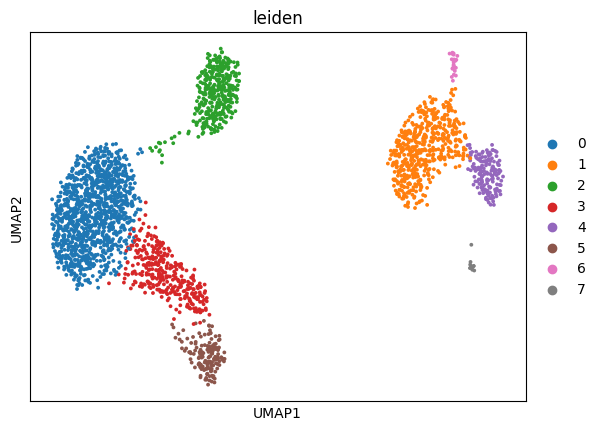

In [7]:
sc.pl.umap(
    adata,
    color=["leiden"],
    size=30,
)

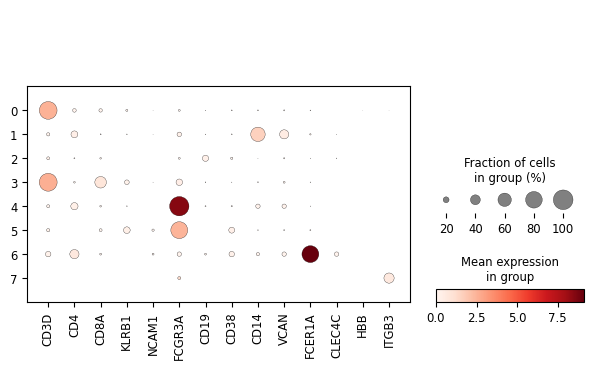

In [8]:
sc.pl.dotplot(adata, var_names=['CD3D', 'CD4', 'CD8A', 'KLRB1', 'NCAM1', 'FCGR3A', 'CD19', 'CD38', 'CD14', 'VCAN', 'FCER1A', 'CLEC4C', 'HBB', 'ITGB3'], groupby='leiden')

The above is a very simplistic overview of some information that will help us classify the cells present in the dataset: spatial relationships in the gene space by dimensionality reduction with UMAP and gene expression on an aggregated per-cluster level in the dotplot. While one must be careful assigning meaning to spatial relationships on a UMAP during cell-type labelling, these two plots shall suffice for the purpose of cell-type labelling in this short tutorial without any claim to completeness.

In [9]:
# Map Leiden clusters to cell type labels based on the dotplot and known marker genes for each cell type
adata.obs['label'] = adata.obs['leiden'].map(
    {
        '0': 'CD4 T cells',
        '1': 'Classical monocytes',
        '2': 'B cells', # probably includes both antigen-naive and antigen-experienced B cells
        '3': 'CD8 T cells',
        '4': 'Non-classical monocytes',
        '5': 'ILCs', # in the sense of both NK cells and other ILCs
        '6': 'Dendritic cells',
        '7': 'Thrombocyte-like cells'
    }
)

In [10]:
adata.obs['label'].isna().any()

np.False_

This is where it gets interesting. We have assigned, by cluster, one label per cell. This is the input data cell type classifiers usually receive. 
To harness the potential of Compocyte's structure, we need to explicitly define a hierarchy on which all above labels can be found. This will help the classifier weight relationships between different cell type labels and define branching points in the classification process that can be modified by exchange or extension down the road.

A simple such hierarchy would be:

In [11]:
from Compocyte.core.tools import make_graph_from_edges
import networkx as nx

hierarchy = {
    'Blood': {
        'Lymphoid': {
            'T cells': {'CD4 T cells': {}, 'CD8 T cells': {}},
            'B cells': {},
            'ILCs': {}
        },
        'Myeloid': {
            'Monocytes': {'Classical monocytes': {}, 'Non-classical monocytes': {}},
            'Dendritic cells': {}
        },        
        'Thrombocyte-like cells': {}
    }
}
graph = nx.DiGraph()
make_graph_from_edges(hierarchy, graph)

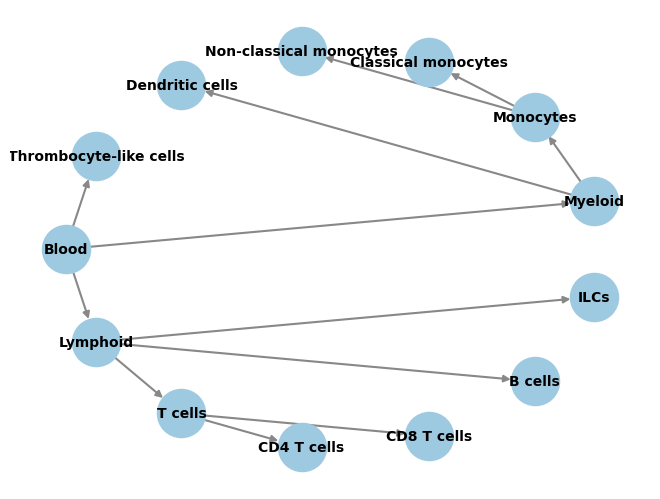

In [12]:
pos = nx.shell_layout(graph)

nx.draw(
    graph, pos,
    with_labels=True,
    node_color="#9ecae1",
    node_size=1200,
    edge_color="#888",
    width=1.5,
    font_size=10,
    font_weight="bold",
)

## Training the classifier

We have now defined cell type labels and a hierarchy that fits these labels and that can tell how we want our classifier structure to be set up. However there is still a small task to be completed before we can begin training.

To provide training labels for training local classifiers at every branching point, we need to infer the intermediate labels of each cell in the hierarchy. This is done by using the `infer_levels` function takes in the hierarchy, the name of the column in `adata.obs` that contains the cell type labels, the name of the root node in the hierarchy, and the `adata` object itself. It adds the level annnotations as separate obs columns in the provided AnnData object and returns as `obs_names` the column names it used. These can then be passed to the classifier so it knows where to look.

In [13]:
from Compocyte.core.tools import infer_levels

# Save level labels to adata.obs and receive the list of obs columns where they have been saved.
_, obs_names = infer_levels(
    hierarchy=hierarchy, 
    labels='label', 
    root_node='Blood', 
    adata=adata
)

In [14]:
obs_names

['Level_0', 'Level_1', 'Level_2', 'Level_3']

In [15]:
adata.obs

,leiden,label,Level_0,Level_1,Level_2,Level_3
index,,,,,,
AAACATACAACCAC-1,3,CD8 T cells,Blood,Lymphoid,T cells,CD8 T cells
AAACATTGAGCTAC-1,2,B cells,Blood,Lymphoid,B cells,
AAACATTGATCAGC-1,0,CD4 T cells,Blood,Lymphoid,T cells,CD4 T cells
AAACCGTGCTTCCG-1,1,Classical monocytes,Blood,Myeloid,Monocytes,Classical monocytes
AAACCGTGTATGCG-1,5,ILCs,Blood,Lymphoid,ILCs,
...,...,...,...,...,...,...
TTTCGAACTCTCAT-1,1,Classical monocytes,Blood,Myeloid,Monocytes,Classical monocytes
TTTCTACTGAGGCA-1,2,B cells,Blood,Lymphoid,B cells,
TTTCTACTTCCTCG-1,2,B cells,Blood,Lymphoid,B cells,


In [16]:
from Compocyte.core.hierarchical_classifier import HierarchicalClassifier

# Train the hierarchical classifier. This will train a separate classifier for each parent node in the hierarchy.
classifier = HierarchicalClassifier(
    save_path="./exclude/pbmc_classifier", 
    adata=adata, 
    root_node='Blood', 
    dict_of_cell_relations=hierarchy, 
    obs_names=obs_names)
classifier.train_all_child_nodes()

Training at Blood.


/usr/local/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  38   65  100  101  107  129  138  150  183  190  202  211  233  240
  252  270  279  297  317  320  330  394  438  441  490  501  532  572
  579  677  690  693  719  870  883  905  908  956  960  968  977  993
 1011 1033 1036 1040 1068 1078 1099 1102 1111 1123 1140 1146 1162 1164
 1176 1201 1223 1290 1312 1343 1350 1354 1402 1407 1424 1428 1446 1465
 1476 1487 1511 1520 1598 1623 1654 1669 1694 1721 1723 1725 1728 1738
 1765 1786 1858 1861 1889 1897 1901 1923 1983 1984] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Training at Lymphoid.


/usr/local/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [   9   38   48   65   79   89   91  100  101  107  116  129  138  150
  183  190  202  211  215  231  233  235  240  252  270  276  279  297
  317  320  321  323  330  345  354  361  368  394  435  438  440  441
  444  455  458  490  501  532  544  546  556  568  572  579  588  606
  611  640  649  677  690  693  696  700  719  762  766  795  797  814
  818  835  837  870  872  883  894  897  905  908  910  913  919  941
  956  960  966  968  977  993 1003 1011 1015 1028 1032 1033 1036 1038
 1040 1041 1058 1067 1068 1072 1078 1089 1099 1102 1111 1123 1140 1146
 1147 1162 1163 1164 1176 1181 1186 1192 1201 1206 1223 1277 1281 1282
 1290 1302 1312 1343 1350 1354 1376 1390 1391 1402 1407 1423 1424 1427
 1428 1431 1439 1446 1454 1465 1469 1476 1487 1494 1511 1520 1537 1552
 1555 1556 1564 1573 1575 1598 1600 1603 1623 1646 1654 1669 1686 1689
 1694 1720 1721 1723 1725 1728

Training at T cells.


/usr/local/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [   2    9   15   25   38   48   55   58   63   77   89   94  100  101
  104  116  117  138  162  167  175  176  182  185  190  203  204  215
  219  226  229  231  235  244  247  261  268  269  272  278  281  297
  301  321  324  327  331  335  344  361  368  391  408  413  417  418
  426  439  440  441  451  456  458  459  476  484  501  527  549  555
  556  561  563  565  568  571  576  588  603  606  611  623  641  649
  703  712  713  724  752  766  771  772  775  778  784  795  797  814
  835  837  846  852  867  872  874  875  876  877  886  894  905  906
  908  910  912  918  919  931  951  953  957  958  962  966  968  970
  993  994 1002 1003 1006 1011 1028 1032 1038 1041 1051 1058 1069 1074
 1075 1089 1091 1099 1118 1125 1126 1139 1157 1163 1179 1186 1195 1198
 1201 1210 1219 1226 1234 1252 1253 1259 1277 1282 1291 1302 1354 1360
 1366 1376 1377 1378 1379 1380

Training at Myeloid.


/usr/local/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [   2    9   15   25   38   48   55   58   63   77   89   94  100  101
  104  116  117  138  162  167  175  176  182  185  190  203  204  215
  219  226  229  231  235  244  247  261  268  269  272  275  278  281
  297  301  321  324  327  331  335  344  361  362  368  391  408  413
  417  418  426  439  440  441  451  456  458  459  476  484  501  527
  549  555  556  561  563  565  568  571  576  588  603  606  611  623
  641  649  703  708  712  713  724  752  766  771  772  775  778  784
  795  797  814  835  837  846  852  867  872  874  875  876  877  886
  894  905  906  908  910  912  918  919  931  951  953  957  958  962
  966  968  970  993  994 1002 1003 1006 1011 1027 1028 1032 1038 1041
 1051 1058 1069 1074 1075 1089 1091 1099 1109 1118 1125 1126 1139 1157
 1163 1179 1186 1195 1198 1201 1210 1219 1226 1234 1252 1253 1259 1277
 1282 1291 1302 1354 1360 1366

Training at Monocytes.


In [ ]:
# Make sure the classifier has been trained by also predicting on the training data. 
# This will add columns with predicted labels to adata.obs for each parent node in the hierarchy.
classifier.predict_all_child_nodes('Blood')

Predicting at Blood.
Predicting at Lymphoid.
Predicting at T cells.
Predicting at Myeloid.
Predicting at Monocytes.


In [18]:
classifier.adata.obs

,leiden,label,Level_0,Level_1,Level_2,Level_3,Level_1_pred,Level_2_pred,Level_3_pred
index,,,,,,,,,
AAACATACAACCAC-1,3,CD8 T cells,Blood,Lymphoid,T cells,CD8 T cells,Lymphoid,T cells,CD4 T cells
AAACATTGAGCTAC-1,2,B cells,Blood,Lymphoid,B cells,,Lymphoid,B cells,
AAACATTGATCAGC-1,0,CD4 T cells,Blood,Lymphoid,T cells,CD4 T cells,Lymphoid,T cells,CD4 T cells
AAACCGTGCTTCCG-1,1,Classical monocytes,Blood,Myeloid,Monocytes,Classical monocytes,Myeloid,Monocytes,Classical monocytes
AAACCGTGTATGCG-1,5,ILCs,Blood,Lymphoid,ILCs,,Lymphoid,ILCs,
...,...,...,...,...,...,...,...,...,...
TTTCGAACTCTCAT-1,1,Classical monocytes,Blood,Myeloid,Monocytes,Classical monocytes,Myeloid,Monocytes,Classical monocytes
TTTCTACTGAGGCA-1,2,B cells,Blood,Lymphoid,B cells,,Lymphoid,B cells,
TTTCTACTTCCTCG-1,2,B cells,Blood,Lymphoid,B cells,,Lymphoid,B cells,


In [19]:
classifier.save()

Congratulations. You have trained your own Compocyte classifier. Check out the other tutorials to see how it can be used!